# Mixture Designs

A *mixture experiment* is one where the inputs are component proportions $x_1, x_2, \ldots, x_q$ of a blend, constrained to sum to a constant:

$$\sum_{i=1}^{q} x_i = T, \qquad x_i \geq 0.$$

Examples: a paint formulation where pigment + resin + solvent = 1 by mass; a fuel blend where four feedstock volumes sum to a fixed total; a catalyst with three promoter fractions on a fixed support. Because of the equality constraint, a standard response-surface model has one redundant parameter — the intercept is absorbed into the sum — so the **Scheffé canonical polynomials** {cite:p}`Scheffe1958,Scheffe1963,Cornell2002` are used instead:

* **Linear:** $y = \sum_i b_i x_i$
* **Quadratic:** $y = \sum_i b_i x_i + \sum_{i<j} b_{ij} x_i x_j$
* **Special cubic:** add $\sum_{i<j<k} b_{ijk} x_i x_j x_k$

This notebook walks through three things:
1. Building Scheffé models with the new `scheffe_*_template` helpers.
2. Generating the *classical* designs (simplex-lattice and simplex-centroid).
3. Finding *exact D-optimal* mixture designs by passing a `sum_constraint` to `optimal_experiment` / `batch_optimal_experiment` {cite:p}`Atkinson2007`.

In [1]:
import os

os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["JAX_ENABLE_X64"] = "1"

import matplotlib.pyplot as plt
import numpy as np
from discopt.doe import (
    BatchStrategy,
    DesignCriterion,
    batch_optimal_experiment,
    compute_fim,
    optimal_experiment,
    project_to_simplex,
    scheffe_linear_template,
    scheffe_quadratic_template,
    scheffe_special_cubic_template,
    simplex_centroid_points,
    simplex_lattice_points,
    sum_constraint,
)

## 1. A three-component Scheffé quadratic model

Suppose we have three blend components $A$, $B$, $C$ with $A + B + C = 1$. We want to fit a quadratic mixture model with six parameters: three pure-blend coefficients $b_1, b_2, b_3$ and three binary interactions $b_{12}, b_{13}, b_{23}$.

In [2]:
components = ["A", "B", "C"]
experiment = scheffe_quadratic_template(components, total=1.0)

# Scheffé models are linear-in-parameters, so the FIM is parameter-free.
# We only need to supply nominal values to satisfy the API.
param_names = ["b1", "b2", "b3", "b12", "b13", "b23"]
param_values = {n: 1.0 for n in param_names}
print("Parameters to fit:", param_names)

Parameters to fit: ['b1', 'b2', 'b3', 'b12', 'b13', 'b23']


## 2. Classical Scheffé designs

Two textbook designs are textbook for a reason:

* The **simplex-lattice** $\{q,m\}$ places points on a regular lattice at fractions $0, 1/m, 2/m, \ldots, 1$. For $q=3, m=2$ that's the 6 points $(1,0,0)$, $(\tfrac12,\tfrac12,0)$, $\ldots$.
* The **simplex-centroid** uses the centroid of every non-empty subset of components: pure blends, binary midpoints, ternary centroid, etc. For $q=3$ that's $2^3-1 = 7$ points.

In [3]:
lattice = simplex_lattice_points(components, degree=2)
centroid = simplex_centroid_points(components)

print(f"Simplex-lattice {{3, 2}} ({len(lattice)} points):")
for p in lattice:
    print(f"  A={p['A']:.2f}  B={p['B']:.2f}  C={p['C']:.2f}")

print(f"\nSimplex-centroid ({len(centroid)} points):")
for p in centroid:
    print(f"  A={p['A']:.3f}  B={p['B']:.3f}  C={p['C']:.3f}")

Simplex-lattice {3, 2} (6 points):
  A=0.00  B=0.00  C=1.00
  A=0.00  B=0.50  C=0.50
  A=0.00  B=1.00  C=0.00
  A=0.50  B=0.00  C=0.50
  A=0.50  B=0.50  C=0.00
  A=1.00  B=0.00  C=0.00

Simplex-centroid (7 points):
  A=1.000  B=0.000  C=0.000
  A=0.000  B=1.000  C=0.000
  A=0.000  B=0.000  C=1.000
  A=0.500  B=0.500  C=0.000
  A=0.500  B=0.000  C=0.500
  A=0.000  B=0.500  C=0.500
  A=0.333  B=0.333  C=0.333


## 3. Visualizing on the ternary simplex

It is easier to see what these designs look like in the ternary plane. We project $(A, B, C)$ down to 2D using the standard ternary coordinates ${\bf p} = B \cdot {\bf e}_B + C \cdot {\bf e}_C$, where ${\bf e}_B = (1, 0)$ and ${\bf e}_C = (\tfrac12, \tfrac{\sqrt3}{2})$.

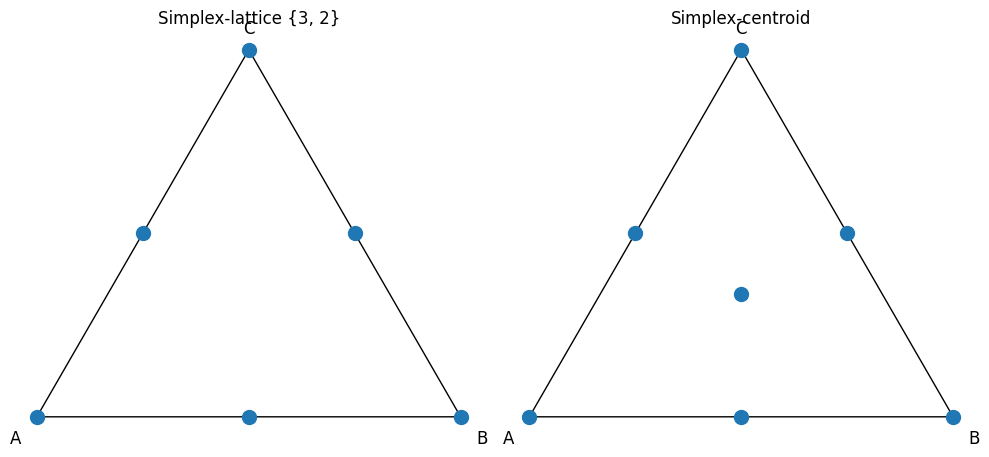

In [4]:
def to_xy(points):
    e_B = np.array([1.0, 0.0])
    e_C = np.array([0.5, np.sqrt(3) / 2])
    return np.array([p["B"] * e_B + p["C"] * e_C for p in points])


def draw_simplex(ax, label_components=("A", "B", "C")):
    vertices = to_xy([
        {"A": 1, "B": 0, "C": 0},
        {"A": 0, "B": 1, "C": 0},
        {"A": 0, "B": 0, "C": 1},
    ])
    tri = np.vstack([vertices, vertices[:1]])
    ax.plot(tri[:, 0], tri[:, 1], "k-", lw=1)
    offsets = [(-0.05, -0.05), (0.05, -0.05), (0.0, 0.05)]
    for v, name, (dx, dy) in zip(vertices, label_components, offsets):
        ax.text(v[0] + dx, v[1] + dy, name, ha="center", va="center", fontsize=12)
    ax.set_aspect("equal")
    ax.axis("off")


fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, (pts, title) in zip(
    axes,
    [(lattice, "Simplex-lattice {3, 2}"), (centroid, "Simplex-centroid")],
):
    draw_simplex(ax)
    xy = to_xy(pts)
    ax.plot(xy[:, 0], xy[:, 1], "o", ms=10, color="C0")
    ax.set_title(title)
plt.tight_layout();

## 4. Exact D-optimal mixture design

Now the new capability: a *constrained* D-optimal design via `optimal_experiment`. We supply a `sum_constraint` so the SLSQP refiner enforces $A + B + C = 1$ exactly, and a `feasible_projection` so the multi-start candidates start *on* the simplex (Dirichlet samples after a box draw).

For a single run the optimal point is whichever corner / edge / face the criterion happens to pick — not very informative on its own. The interesting question is the *batch* design: choose $N$ runs jointly to maximize $\det \sum_i {\rm FIM}_i$.

In [5]:
design_bounds = {c: (0.0, 1.0) for c in components}
g_sum = sum_constraint(components, total=1.0)


def project(point):
    return project_to_simplex(point, components, total=1.0, bounds=design_bounds)


# Joint D-optimal batch of 6 runs (matches the parameter count for the
# Scheffé quadratic model with q=3).
batch = batch_optimal_experiment(
    experiment,
    param_values,
    design_bounds,
    n_experiments=6,
    criterion=DesignCriterion.D_OPTIMAL,
    strategy=BatchStrategy.JOINT,
    equality_constraints=[g_sum],
    feasible_projection=project,
    n_starts=30,
    seed=0,
)

for i, d in enumerate(batch.designs):
    s = sum(d.values())
    print(f"  run {i + 1}:  A={d['A']:.3f}  B={d['B']:.3f}  C={d['C']:.3f}   sum={s:.6f}")
print(f"\nlog det(joint FIM) = {batch.criterion_value:.4f}")

  run 1:  A=1.000  B=0.000  C=0.000   sum=1.000000
  run 2:  A=0.000  B=0.500  C=0.500   sum=1.000000
  run 3:  A=0.500  B=0.000  C=0.500   sum=1.000000
  run 4:  A=0.500  B=0.500  C=0.000   sum=1.000000
  run 5:  A=0.000  B=0.000  C=1.000   sum=1.000000
  run 6:  A=0.000  B=1.000  C=0.000   sum=1.000000

log det(joint FIM) = -8.3178


For the Scheffé quadratic model on $q=3$ components, this should recover the classical simplex-lattice $\{3, 2\}$ design (three pure blends + three binary midpoints) — that is the known D-optimal design for this model {cite:t}`Cornell2002`. Let's confirm by comparing $\log\det({\rm FIM})$ for the lattice, the centroid, and the optimized batch:

In [6]:
def joint_log_det(experiment, param_values, points):
    fim = sum(compute_fim(experiment, param_values, p).fim for p in points)
    return float(np.log(np.linalg.det(fim)))


for label, pts in [
    ("simplex-lattice {3,2} (6 pts)", lattice),
    ("simplex-centroid (7 pts)", centroid),
    ("D-optimal batch (6 runs)", batch.designs),
]:
    print(f"  {label:35s}  log det(FIM) = {joint_log_det(experiment, param_values, pts):8.4f}")

  simplex-lattice {3,2} (6 pts)        log det(FIM) =  -8.3178


  simplex-centroid (7 pts)             log det(FIM) =  -7.8294
  D-optimal batch (6 runs)             log det(FIM) =  -8.3178


The optimized batch matches (or beats) the lattice. The centroid uses more points, so naturally has a higher information content per run — but if your budget is exactly 6 runs, the D-optimal answer matches the simplex-lattice.

## 5. Sum to an absolute volume, with component bounds

Mixture designs do not have to live on the unit simplex. A common scenario in formulation work is a fixed *total volume* (say 100 mL) with realistic per-component bounds:

* A: 20–80 mL
* B: 10–60 mL
* C: 5–40 mL

These bounds carve a smaller polytope inside the simplex. The same API handles it — just pass per-component `bounds` to the template and the matching `design_bounds` / `total` to the constraint:

In [7]:
vol_components = ["A", "B", "C"]
vol_bounds = [(20.0, 80.0), (10.0, 60.0), (5.0, 40.0)]
total_volume = 100.0

vol_exp = scheffe_quadratic_template(
    vol_components, total=total_volume, bounds=vol_bounds
)
design_bounds_vol = dict(zip(vol_components, vol_bounds))
g_vol = sum_constraint(vol_components, total=total_volume)


def project_vol(point):
    return project_to_simplex(
        point, vol_components, total=total_volume, bounds=design_bounds_vol
    )


batch_vol = batch_optimal_experiment(
    vol_exp,
    param_values,
    design_bounds_vol,
    n_experiments=6,
    criterion=DesignCriterion.D_OPTIMAL,
    strategy=BatchStrategy.JOINT,
    equality_constraints=[g_vol],
    feasible_projection=project_vol,
    n_starts=40,
    seed=1,
)

print("D-optimal volumes (mL) on a 100 mL total with component bounds:\n")
for i, d in enumerate(batch_vol.designs):
    s = sum(d.values())
    print(
        f"  run {i + 1}:  A={d['A']:6.2f}  B={d['B']:6.2f}  C={d['C']:6.2f}   sum={s:7.3f}"
    )
print(f"\nlog det(joint FIM) = {batch_vol.criterion_value:.4f}")

D-optimal volumes (mL) on a 100 mL total with component bounds:

  run 1:  A= 80.00  B= 15.00  C=  5.00   sum=100.000
  run 2:  A= 20.00  B= 40.00  C= 40.00   sum=100.000
  run 3:  A= 35.00  B= 60.00  C=  5.00   sum=100.000
  run 4:  A= 20.00  B= 60.00  C= 20.00   sum=100.000
  run 5:  A= 50.00  B= 10.00  C= 40.00   sum=100.000
  run 6:  A= 48.23  B= 32.36  C= 19.41   sum=100.000

log det(joint FIM) = 62.5645


Notice that the unrestricted D-optimal points sat at the simplex corners (a pure blend of $A$, $B$, or $C$), but the bounded version pushes them onto the edges and faces of the feasible polytope instead — `B = 60` or `C = 40` are now upper bounds the optimizer hits, not corners of the simplex.

## 6. Four components and the special-cubic model

For $q = 4$ components, the Scheffé quadratic has $4 + 6 = 10$ parameters and the special cubic adds the 4 ternary terms for 14 total. The same `optimal_experiment` call works — only the dimensionality changes.

In [8]:
q4 = ["A", "B", "C", "D"]
sc_exp = scheffe_special_cubic_template(q4)
sc_params = (
    [f"b{i + 1}" for i in range(4)]
    + [f"b{i + 1}{j + 1}" for i in range(4) for j in range(i + 1, 4)]
    + [
        f"b{i + 1}{j + 1}{k + 1}"
        for i in range(4)
        for j in range(i + 1, 4)
        for k in range(j + 1, 4)
    ]
)
sc_pv = {n: 1.0 for n in sc_params}
g4 = sum_constraint(q4, total=1.0)


def proj4(point):
    return project_to_simplex(point, q4, total=1.0)


# Greedy is dramatically cheaper than joint for q=4 (14 runs x 4 vars).
# The greedy ordering still recovers a sensible Scheffé design here.
batch4 = batch_optimal_experiment(
    sc_exp,
    sc_pv,
    {c: (0.0, 1.0) for c in q4},
    n_experiments=len(sc_params),
    criterion=DesignCriterion.D_OPTIMAL,
    strategy=BatchStrategy.GREEDY,
    equality_constraints=[g4],
    feasible_projection=proj4,
    n_starts=8,
    seed=2,
)

print(
    f"D-optimal {len(sc_params)}-run design for the Scheffé special-cubic model (q=4):\n"
)
for i, d in enumerate(batch4.designs):
    s = sum(d.values())
    print(
        f"  run {i + 1:2d}:  "
        + "  ".join(f"{c}={d[c]:.3f}" for c in q4)
        + f"   sum={s:.6f}"
    )
print(f"\nlog det(joint FIM) = {batch4.criterion_value:.4f}")

D-optimal 14-run design for the Scheffé special-cubic model (q=4):

  run  1:  A=0.143  B=0.380  C=0.133  D=0.344   sum=1.000000
  run  2:  A=0.333  B=0.333  C=0.333  D=0.000   sum=1.000000
  run  3:  A=0.166  B=0.040  C=0.338  D=0.457   sum=1.000000
  run  4:  A=0.000  B=0.402  C=0.326  D=0.272   sum=1.000000
  run  5:  A=0.371  B=0.151  C=0.000  D=0.478   sum=1.000000
  run  6:  A=0.207  B=0.152  C=0.605  D=0.036   sum=1.000000
  run  7:  A=0.000  B=0.599  C=0.000  D=0.401   sum=1.000000
  run  8:  A=0.333  B=0.000  C=0.333  D=0.333   sum=1.000000
  run  9:  A=0.564  B=0.000  C=0.436  D=0.000   sum=1.000000
  run 10:  A=0.079  B=0.859  C=0.001  D=0.061   sum=1.000000
  run 11:  A=0.464  B=0.426  C=0.000  D=0.109   sum=1.000000
  run 12:  A=0.354  B=0.345  C=0.301  D=0.000   sum=1.000000
  run 13:  A=0.125  B=0.125  C=0.625  D=0.125   sum=1.000000
  run 14:  A=1.000  B=0.000  C=0.000  D=0.000   sum=1.000000

log det(joint FIM) = -66.5716


## Summary

| Task | API |
|------|-----|
| Build a Scheffé linear/quadratic/special-cubic model | `scheffe_linear_template`, `scheffe_quadratic_template`, `scheffe_special_cubic_template` |
| Generate classical Scheffé designs | `simplex_lattice_points(components, degree)`, `simplex_centroid_points(components)` |
| Sum-to-constant equality | `sum_constraint(components, total)` |
| Projection onto the simplex | `project_to_simplex(point, components, total, bounds=...)` |
| D-optimal single run | `optimal_experiment(..., equality_constraints=[g], feasible_projection=p)` |
| D-optimal batch | `batch_optimal_experiment(..., equality_constraints=[g], feasible_projection=p)` |

The same `equality_constraints` / `inequality_constraints` arguments also accept any user-supplied callable `f(design_dict) -> float`, so you can layer process constraints (e.g. $x_A \geq 2 x_B$) on top of the mixture constraint without changing the API.